# Test 12
## APCEMM PCE Creation
Aircraft Type: B737-800

Engine Type: CFM56

### Initial Conditions
RHi Mean: 117

RHi Normalized Variance: 100

### Temporal Conditions
RHi Normalized Variance: 0

Static test! ^^^


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [ ]:
test_id = "test_12"

# Load .npy files into variables
coefficients = np.load("/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/APCEMM_PCE_results/{test_id}/PCE_coefficients.npy")
alpha = np.load("/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/APCEMM_PCE_results/{test_id}/PCE_alpha_set.npy")
predicted_validation_solutions = np.load("/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/APCEMM_PCE_results/{test_id}/predicted_validation_solutions.npy")
true_validation_solutions = np.load("/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/APCEMM_PCE_results/{test_id}/true_validation_solutions.npy")
true_training_solutions = np.load("/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/APCEMM_PCE_results/{test_id}/true_training_solutions.npy")
training_samples_matrix_offline = np.load("/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/APCEMM_PCE_results/{test_id}/training_samples_matrix_offline_cleaned.npy")
validation_samples_matrix_offline = np.load("/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_results/APCEMM_PCE_results/{test_id}/validation_samples_matrix_offline_cleaned.npy")
timesteps = len(training_samples_matrix_offline[0,0,:])

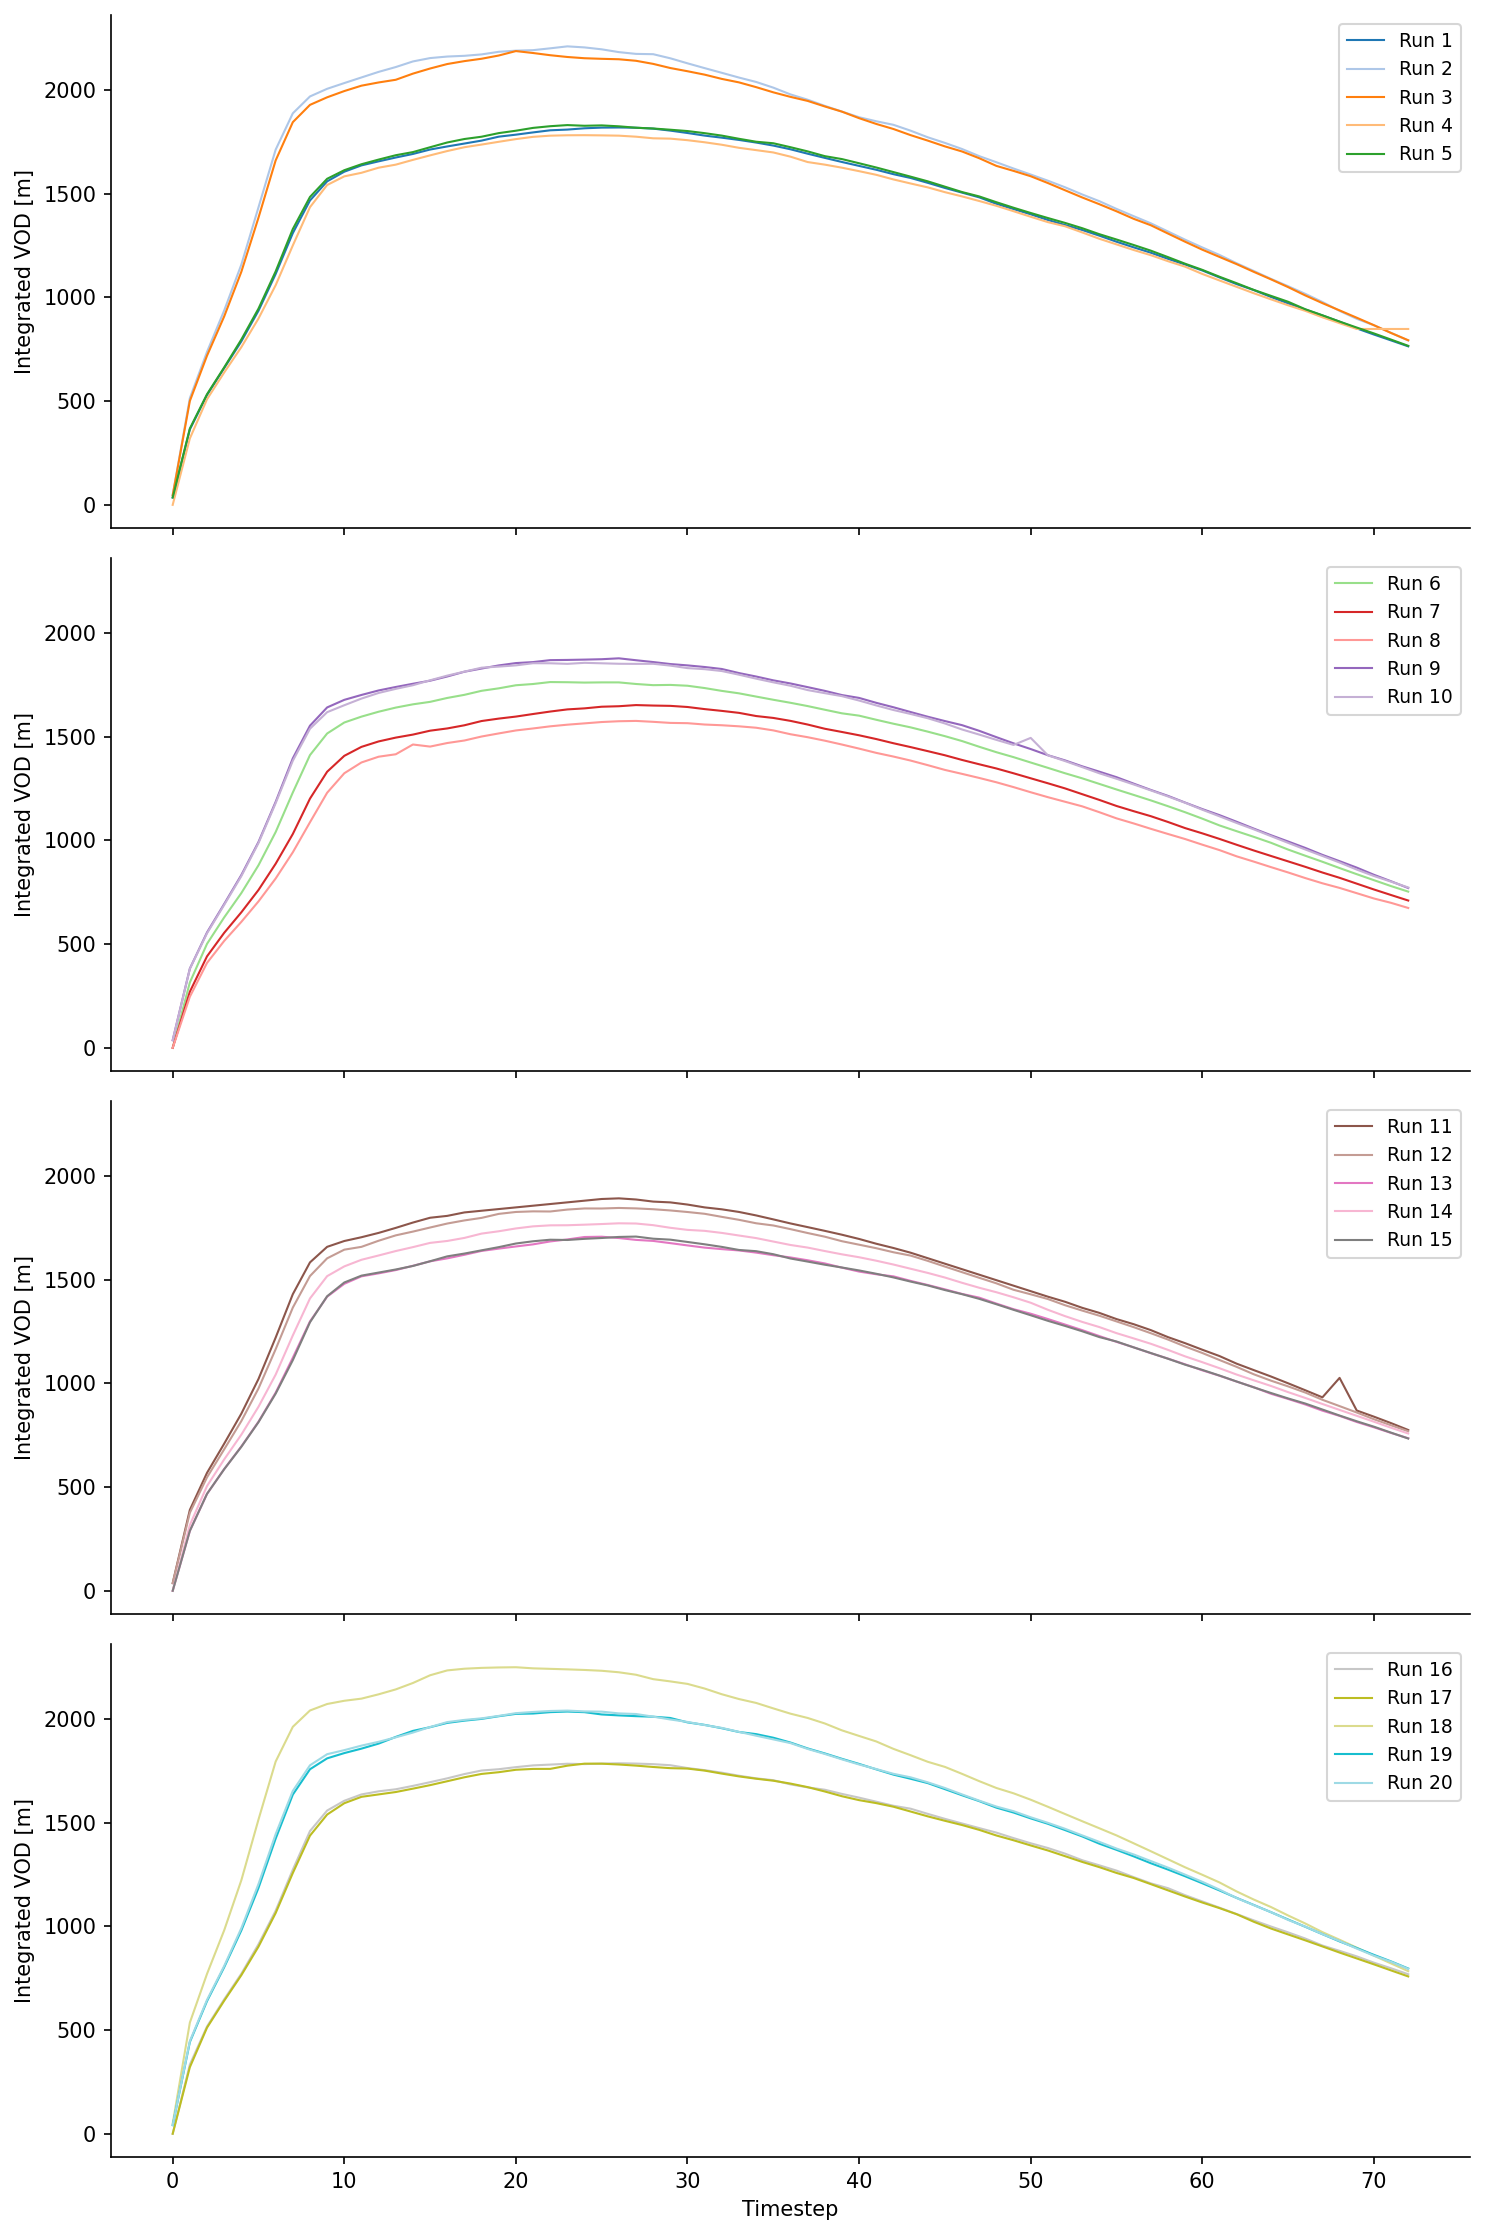

In [ ]:
lw = 1
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 15), dpi=150, sharex=True, sharey=True)
num_colors = len(training_samples_matrix_offline[0,:,0])  # Number of unique colors needed
colors = cm.get_cmap('tab20', num_colors).colors  # Use 'tab20' colormap with `num_colors` unique colors

for subplot_idx, ax in enumerate(axes):
    for idx in range(subplot_idx * 5, (subplot_idx + 1) * 5):
        ax.plot(list(range(0, timesteps)), true_training_solutions[idx, :], label=f"Run {idx+1}", lw=lw, color=colors[idx % len(colors)])
    ax.set_ylabel("Integrated VOD [m]")
    ax.legend(fontsize=9)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

axes[-1].set_xlabel("Timestep")
plt.tight_layout()
plt.show()


### Validation of PCE created surrogate

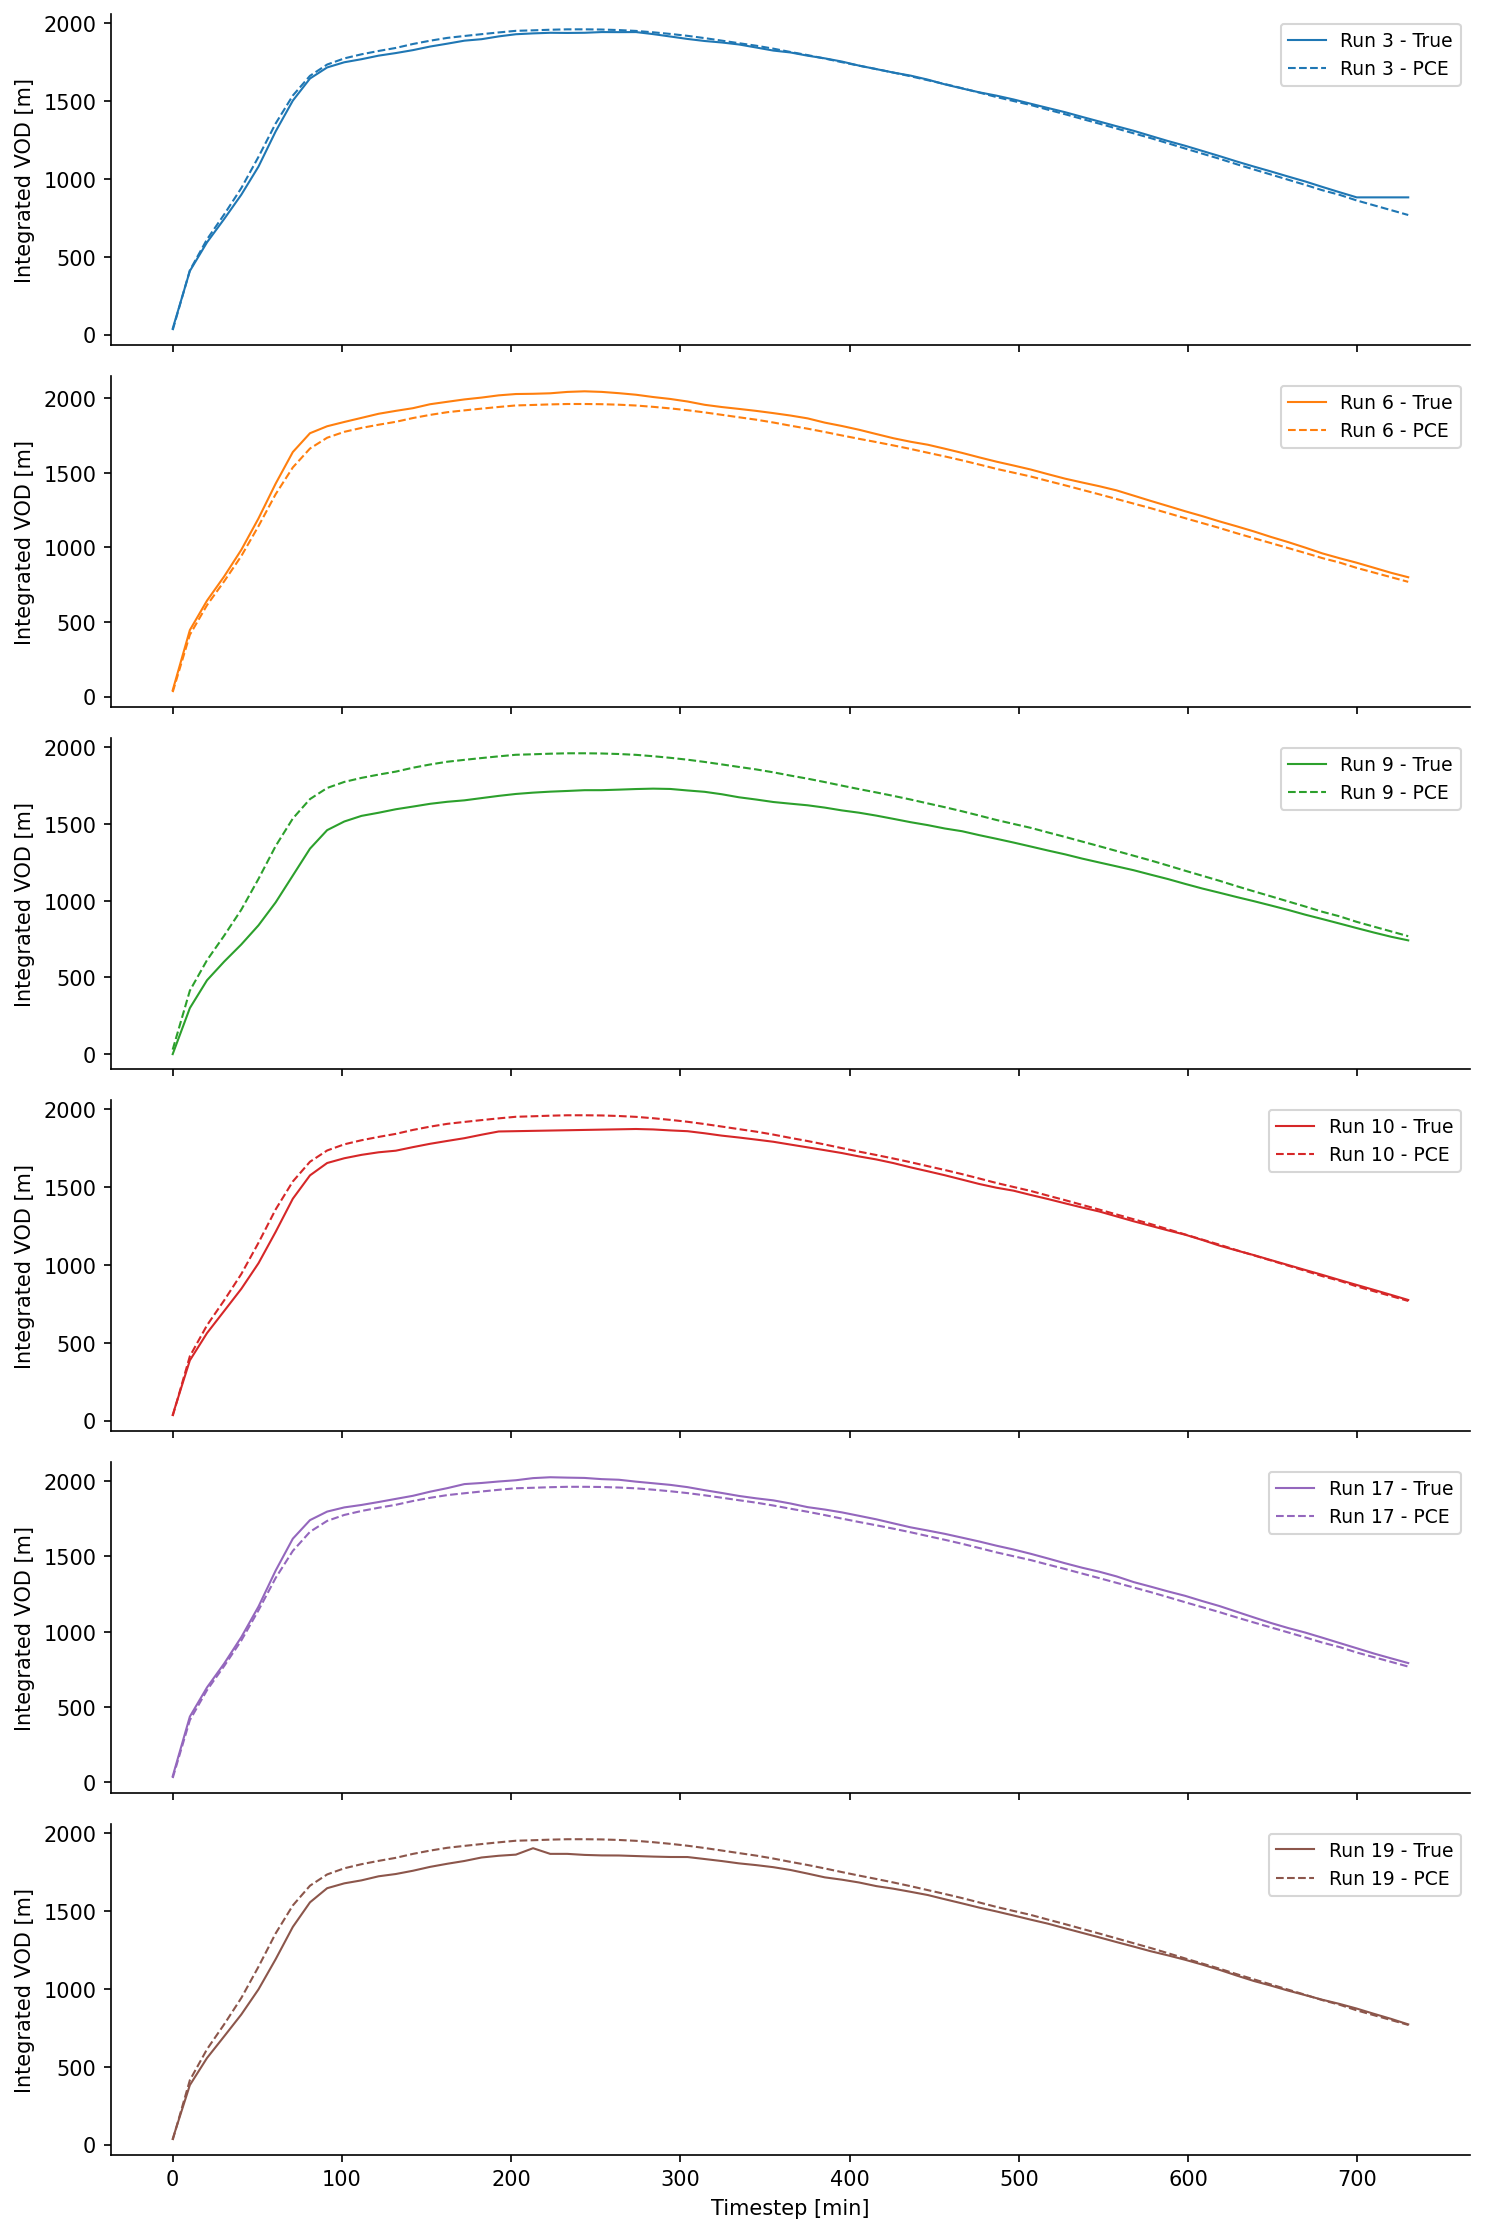

In [9]:
selected_runs = [2, 5, 8, 9, 16, 18]
fig, axes = plt.subplots(nrows=len(selected_runs), ncols=1, figsize=(10, 15), dpi=150, sharex=True)

time_min = timesteps * 10
time_points = np.linspace(0, time_min, timesteps)
line_styles = ["-", "--"]  # Solid, dashed
colors = plt.cm.tab10.colors[:len(selected_runs)]

for idx, run in enumerate(selected_runs):
    run = run + 1
    ax = axes[idx]
    ax.plot(time_points, true_validation_solutions[run, :], label=f"Run {run} - True", color=colors[idx % len(colors)], lw=lw, ls=line_styles[0])
    ax.plot(time_points, predicted_validation_solutions[run, :], label=f"Run {run} - PCE", color=colors[idx % len(colors)], lw=lw, ls=line_styles[1])
    ax.set_ylabel("Integrated VOD [m]")
    ax.legend(fontsize=9)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

axes[-1].set_xlabel("Timestep [min]")
plt.tight_layout()
plt.show()


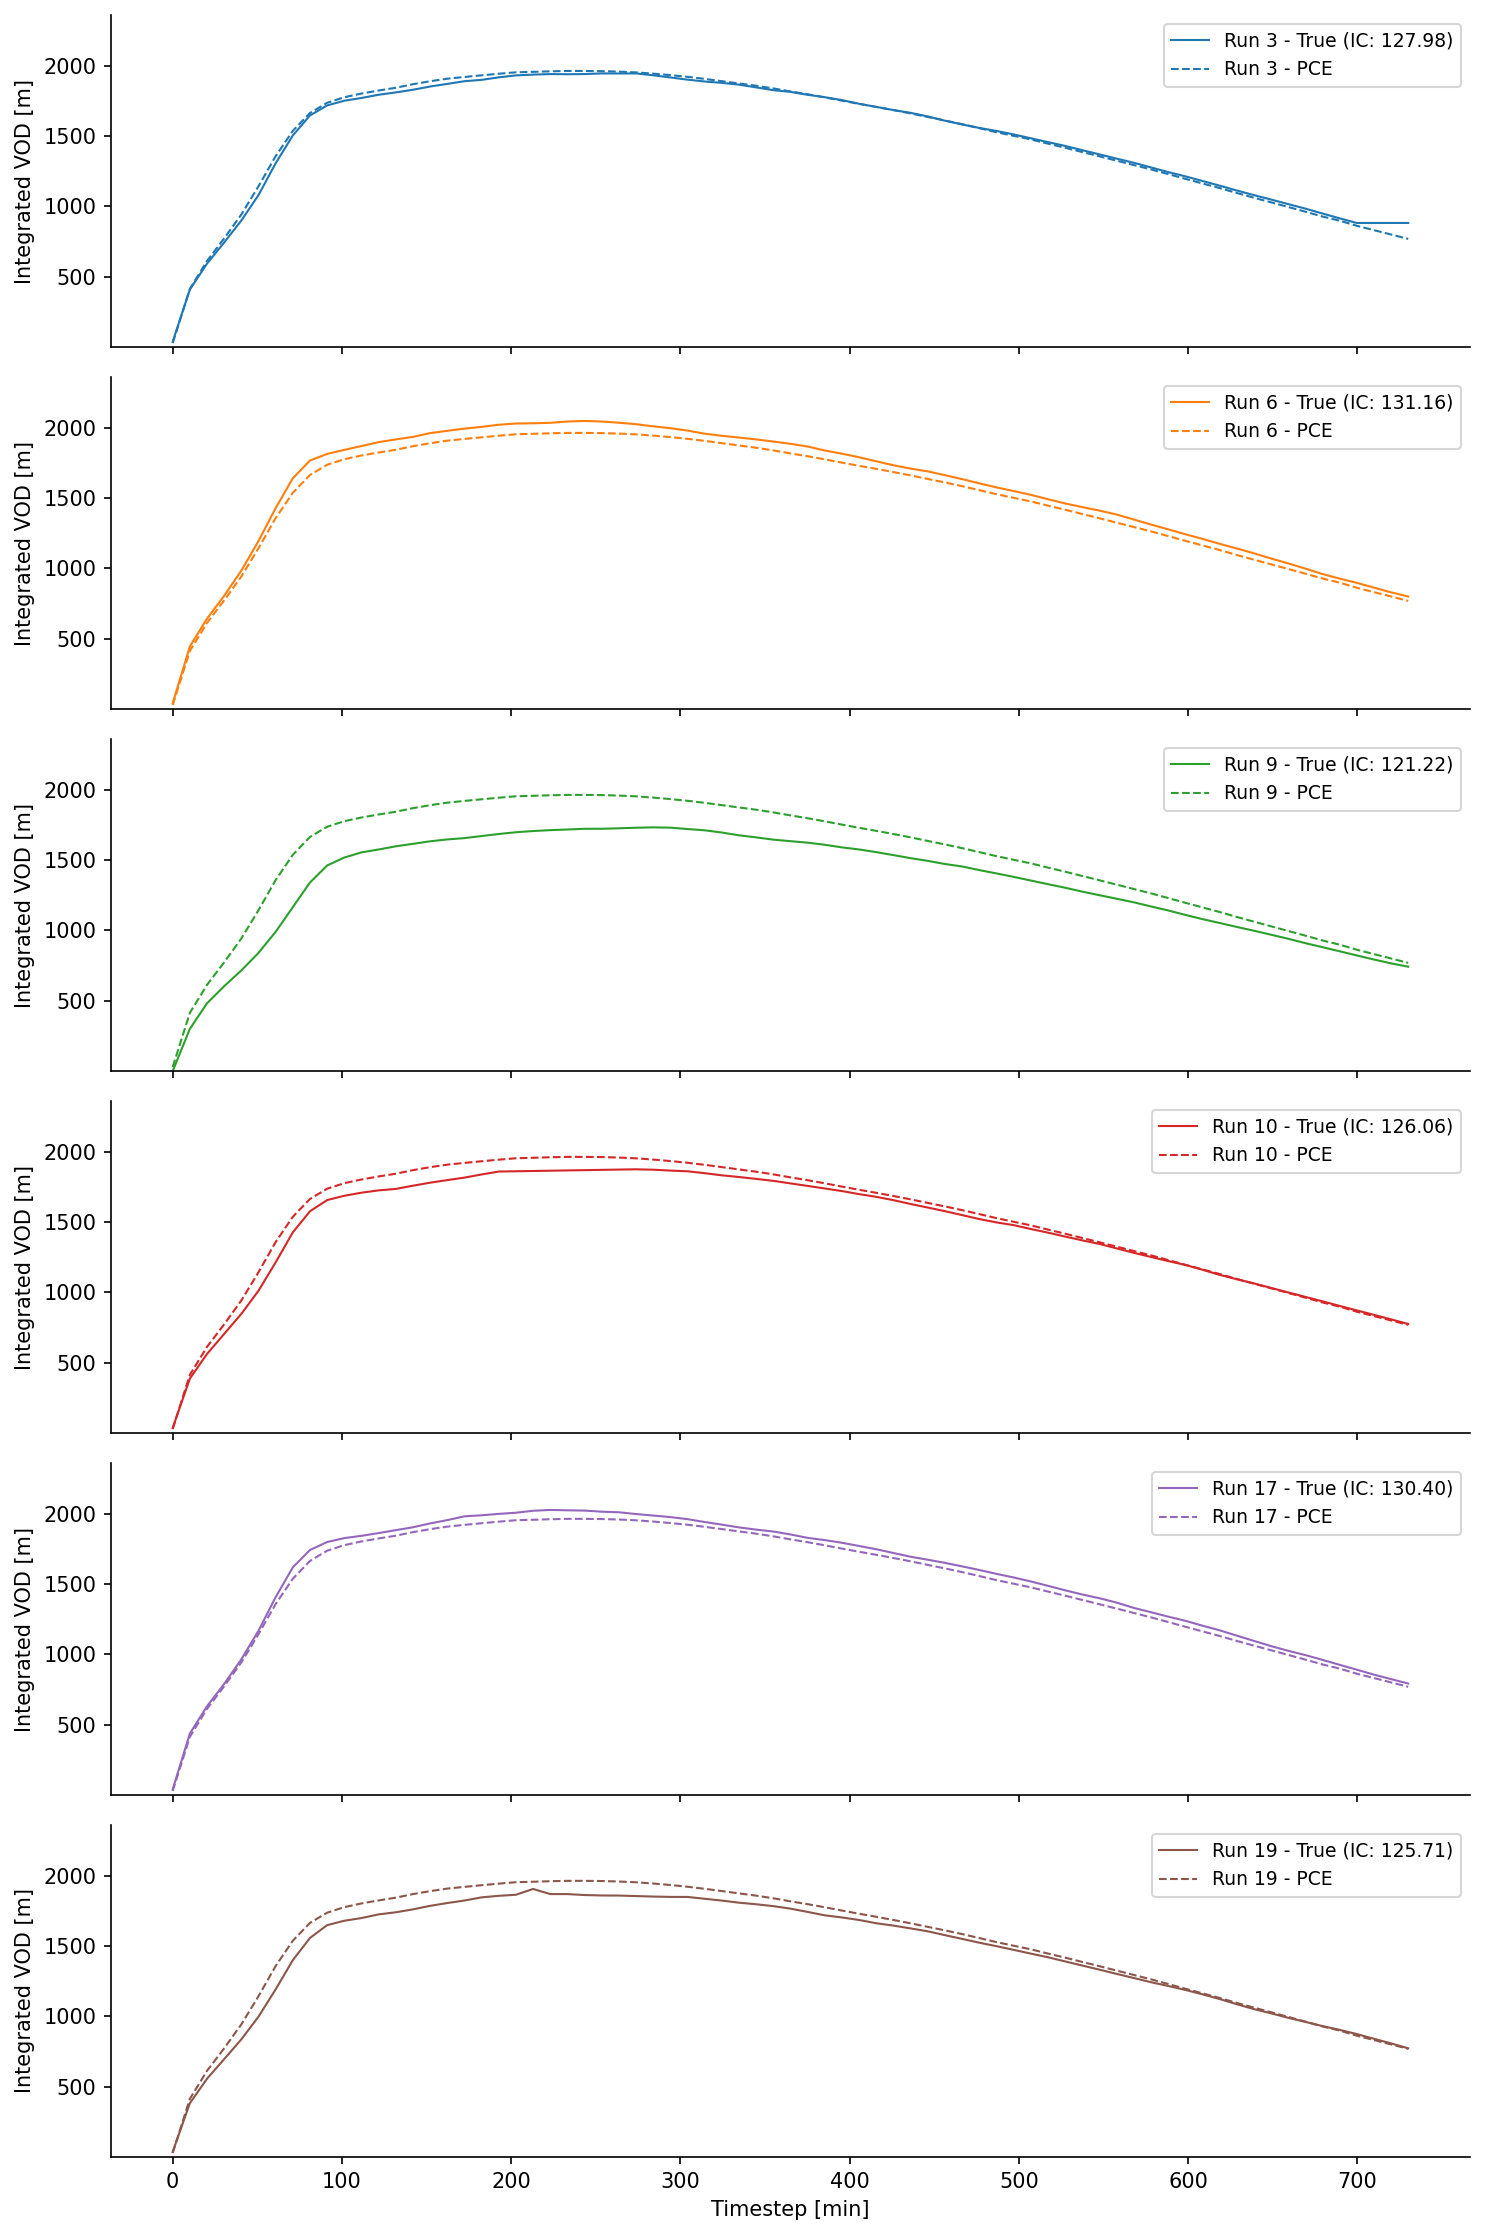

In [10]:
fig, axes = plt.subplots(nrows=len(selected_runs), ncols=1, figsize=(10, 15), dpi=150, sharex=True)

time_min = timesteps * 10
time_points = np.linspace(0, time_min, timesteps)
line_styles = ["-", "--"]  # Solid, dashed
colors = plt.cm.tab10.colors[:len(selected_runs)]

# Determine global y-axis limits
y_min = min(true_validation_solutions.min(), predicted_validation_solutions.min())
y_max = max(true_validation_solutions.max(), predicted_validation_solutions.max())

# Plot each selected validation run
for idx, run in enumerate(selected_runs):
    run = run + 1
    ax = axes[idx]
    initial_condition = validation_samples_matrix_offline[0, run, 0] + 117  # Extract the initial condition for the run
    ax.plot(time_points, true_validation_solutions[run, :], label=f"Run {run} - True (IC: {initial_condition:.2f})", color=colors[idx % len(colors)], lw=lw, ls=line_styles[0])
    ax.plot(time_points, predicted_validation_solutions[run, :], label=f"Run {run} - PCE", color=colors[idx % len(colors)], lw=lw, ls=line_styles[1])
    ax.set_ylabel("Integrated VOD [m]")
    ax.legend(fontsize=9)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_ylim(y_min, y_max)  # Set the same y-axis limits for all subplots

# Set the x-axis label for the last subplot
axes[-1].set_xlabel("Timestep [min]")

# Adjust layout
plt.tight_layout()
plt.show()


In [20]:
# Calculate the average error per point across all runs
average_error_per_point = np.mean((true_validation_solutions - predicted_validation_solutions), axis=0)

# Print the average error for the first few timesteps
print("Average error per point across all runs (first few timesteps):")
print(average_error_per_point[:5])

Average error per point across all runs (first few timesteps):
[ 74.20894483  17.32527853  -6.33530952 -33.2183569  -69.19775982]


[ 7.42089448e+01  1.73252785e+01 -6.33530952e+00 -3.32183569e+01
 -6.91977598e+01 -1.16089747e+02 -1.37076172e+02 -1.27845225e+02
 -1.06740620e+02 -9.27599774e+01 -9.01382439e+01 -8.97857720e+01
 -9.01414648e+01 -9.05238699e+01 -9.74986534e+01 -1.00081487e+02
 -1.00463252e+02 -9.56330716e+01 -9.17541564e+01 -8.79197664e+01
 -8.82764120e+01 -8.14368800e+01 -8.19380006e+01 -8.18880041e+01
 -8.11381735e+01 -8.13506664e+01 -8.08067614e+01 -7.93163579e+01
 -7.76990056e+01 -7.42333399e+01 -7.29917677e+01 -7.13316730e+01
 -6.95722895e+01 -6.73054442e+01 -6.67163308e+01 -6.34179384e+01
 -5.85005571e+01 -5.65975377e+01 -5.35214384e+01 -4.96235175e+01
 -4.77238181e+01 -4.75047192e+01 -4.79595074e+01 -4.76518901e+01
 -4.45030587e+01 -4.42402990e+01 -4.32940424e+01 -4.11585262e+01
 -3.74115974e+01 -3.65026617e+01 -3.77562872e+01 -3.52215735e+01
 -3.38734550e+01 -3.21448090e+01 -3.05341580e+01 -2.95284462e+01
 -2.83299321e+01 -2.75964750e+01 -2.49786374e+01 -2.16581975e+01
 -2.03737896e+01 -1.97305

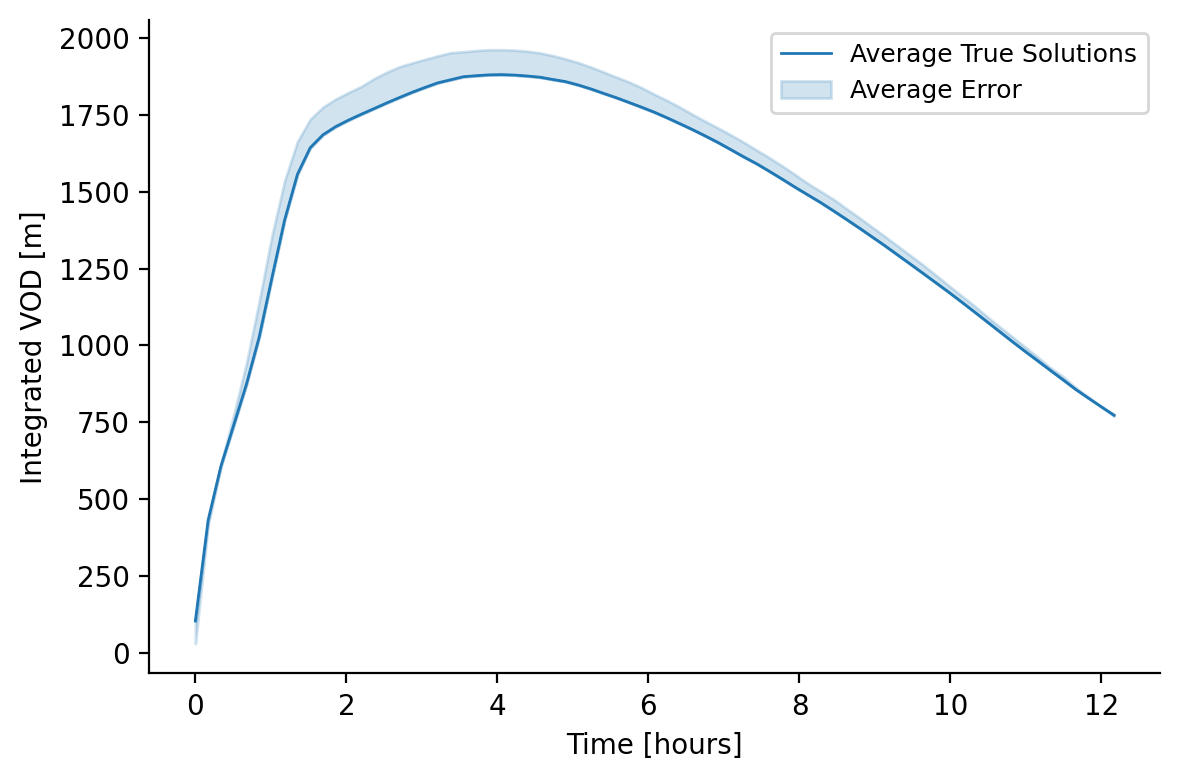

In [34]:
# Calculate the average of the true solutions
average_true_solutions = np.mean(true_validation_solutions, axis=0)
lower_bound = np.zeros(len(average_true_solutions))
upper_bound = np.zeros(len(average_true_solutions))

# Create the plot
fig, ax = plt.subplots(dpi=200)

time_hours = time_points / 60  # Convert time points to hours
colors = plt.cm.tab10.colors[0]  # Use a single color for the plot

# Plot the average of the true solutions
ax.plot(time_hours, average_true_solutions, label="Average True Solutions", color=colors, lw=lw)

# Add shaded region based on the average error per point
for i in range(len(average_error_per_point)):
    if average_error_per_point[i] < 0:
        lower_bound[i] = average_true_solutions[i] - average_error_per_point[i]
    else:
        lower_bound[i] = average_true_solutions[i]
    
    if average_error_per_point[i] >= 0:
        upper_bound[i] = average_true_solutions[i] - average_error_per_point[i]
    else:
        upper_bound[i] = average_true_solutions[i]
print(average_error_per_point)
ax.fill_between(time_hours, lower_bound, average_true_solutions, color=colors, alpha=0.2)
ax.fill_between(time_hours, upper_bound, average_true_solutions, color=colors, alpha=0.2, label="Average Error")

ax.set_ylabel("Integrated VOD [m]")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Set the x-axis label
ax.set_xlabel("Time [hours]")

# Add legend
ax.legend(fontsize=9)

# Adjust layout
plt.tight_layout()
plt.show()

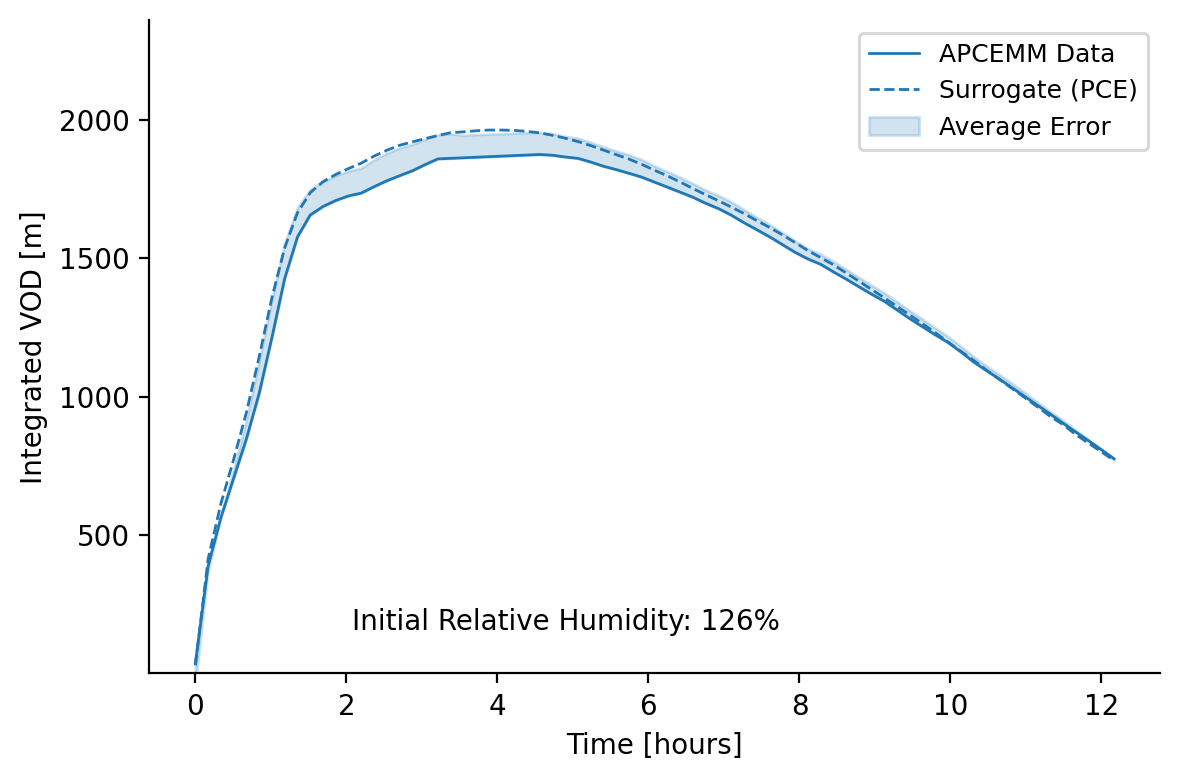

In [38]:
fig, ax = plt.subplots(dpi=200)

time_hours = time_points / 60  # Convert time points to hours
line_styles = ["-", "--"]  # Solid, dashed
colors = plt.cm.tab10.colors[0]  # Use a single color for the plot

# Determine global y-axis limits
y_min = min(true_validation_solutions.min(), predicted_validation_solutions.min())
y_max = max(true_validation_solutions.max(), predicted_validation_solutions.max())

# Plot run 10
run = 10  # Run index
initial_condition = validation_samples_matrix_offline[0, run, 0] + 117  # Extract the initial condition for the run
ax.plot(time_hours, true_validation_solutions[run, :], label=f"APCEMM Data", color=colors, lw=lw, ls=line_styles[0])
ax.plot(time_hours, predicted_validation_solutions[run, :], label=f"Surrogate (PCE)", color=colors, lw=lw, ls=line_styles[1])

#------------------------------------------------------------------------------------------------------------------------------------
# Add shaded region based on the average error per point
for i in range(len(average_error_per_point)):
    if average_error_per_point[i] < 0:
        lower_bound[i] = true_validation_solutions[run, i] - average_error_per_point[i]
    else:
        lower_bound[i] = true_validation_solutions[run, i]
    
    if average_error_per_point[i] >= 0:
        upper_bound[i] = true_validation_solutions[run, i] - average_error_per_point[i]
    else:
        upper_bound[i] = true_validation_solutions[run, i]

ax.fill_between(time_hours, lower_bound, upper_bound, color=colors, alpha=0.2, label="Average Error")
#------------------------------------------------------------------------------------------------------------------------------------

ax.set_ylabel("Integrated VOD [m]")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.set_ylim(y_min, y_max)  # Set the same y-axis limits

# Add the initial condition as a text annotation
ax.text(0.20, 0.1, f"Initial Relative Humidity: {initial_condition:.0f}%", transform=ax.transAxes, fontsize=10, verticalalignment='top')

# Set the x-axis label
ax.set_xlabel("Time [hours]")

# Add legend
ax.legend(fontsize=9)

# Adjust layout
plt.tight_layout()
plt.show()


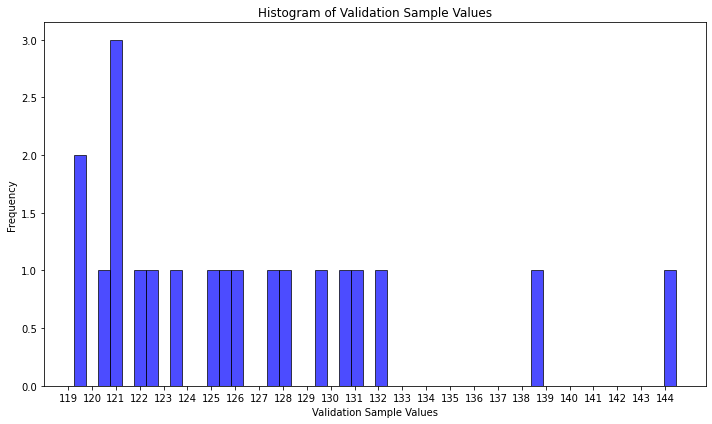

In [13]:
# Flatten the validation samples to create a 1D array for the histogram
data = validation_samples_matrix_offline[0, :, 0] + 117

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, alpha=0.7, color='blue', edgecolor='black')

# Add integer ticks for the x-axis
x_ticks = range(int(data.min()), int(data.max()) + 1)  # Generate integer ticks
plt.xticks(x_ticks)

plt.xlabel("Validation Sample Values")
plt.ylabel("Frequency")
plt.title("Histogram of Validation Sample Values")
plt.tight_layout()
plt.show()


# Sensitivity Analysis of Novel-Sampled PCE Solutions

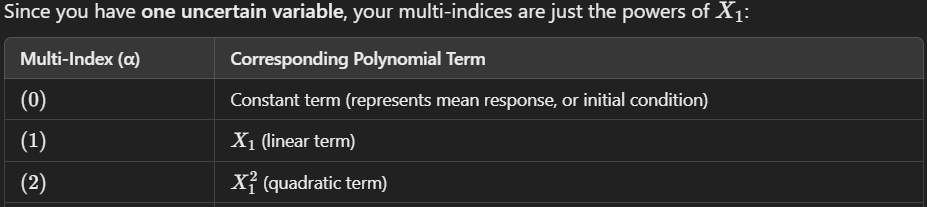

In [14]:
from IPython.display import Image

# Display the image
image_path = '/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_processing/multi_indices_expl.png'
Image(filename=image_path)

In [15]:
# Example usage
num_variables = 3
S_T = compute_total_effect_sensitivity_indices(coefficients, num_variables)

# Print the total effect sensitivity indices for the first few timesteps
print("Total Effect Sensitivity Indices (S_T) for first few timesteps:")
for key, values in S_T.items():
    print(f"{key}: {values[:5]}")  # Print first 5 timesteps for brevity

Total Effect Sensitivity Indices (S_T) for first few timesteps:
S_T_0: [  6.08568577 165.3516018  513.43145203 602.66865623 517.67096535]
S_T_1: [0.99885817 0.99968198 0.9999322  0.99999193 0.99999999]
S_T_2: [1.14182938e-03 3.18015434e-04 6.78035366e-05 8.07352026e-06
 1.09355356e-08]
